<a href="https://colab.research.google.com/github/suraj-75/laughing-train/blob/main/Facial_Emotions_Recognition_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!unzip archive.zip

Archive:  archive.zip
  inflating: emotions.csv            
  inflating: images/0/Anger.jpg      
  inflating: images/0/Contempt.jpg   
  inflating: images/0/Disgust.jpg    
  inflating: images/0/Fear.jpg       
  inflating: images/0/Happy.jpg      
  inflating: images/0/Neutral.jpg    
  inflating: images/0/Sad.jpg        
  inflating: images/0/Surprised.jpg  
  inflating: images/1/Anger.jpg      
  inflating: images/1/Contempt.jpg   
  inflating: images/1/Disgust.jpg    
  inflating: images/1/Fear.jpg       
  inflating: images/1/Happy.jpg      
  inflating: images/1/Neutral.jpg    
  inflating: images/1/Sad.jpg        
  inflating: images/1/Surprised.jpg  
  inflating: images/10/Anger.jpg     
  inflating: images/10/Contempt.jpg  
  inflating: images/10/Disgust.jpg   
  inflating: images/10/Fear.jpg      
  inflating: images/10/Happy.jpg     
  inflating: images/10/Neutral.jpg   
  inflating: images/10/Sad.jpg       
  inflating: images/10/Surprised.jpg  
  inflating: images/11/Ange

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import itertools

In [47]:
img_size = 48
Data_Dir = '/content/images'
EMOTIONS = ['Angry', 'Contempt', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

csv_path = '/content/emotions.csv'
emotions_df = pd.read_csv(csv_path)

In [7]:
emotions_df['set_id'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18])

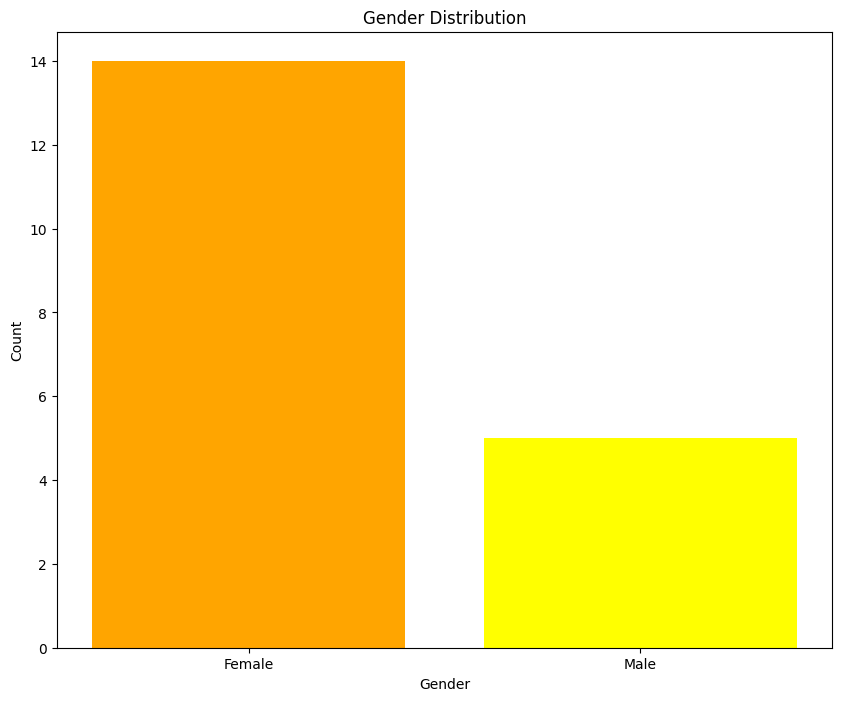

In [9]:
plt.figure(figsize=(10, 8))
gender_counts = emotions_df['gender'].value_counts()
plt.bar(gender_counts.index, gender_counts.values, color=['orange', 'yellow'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.show()

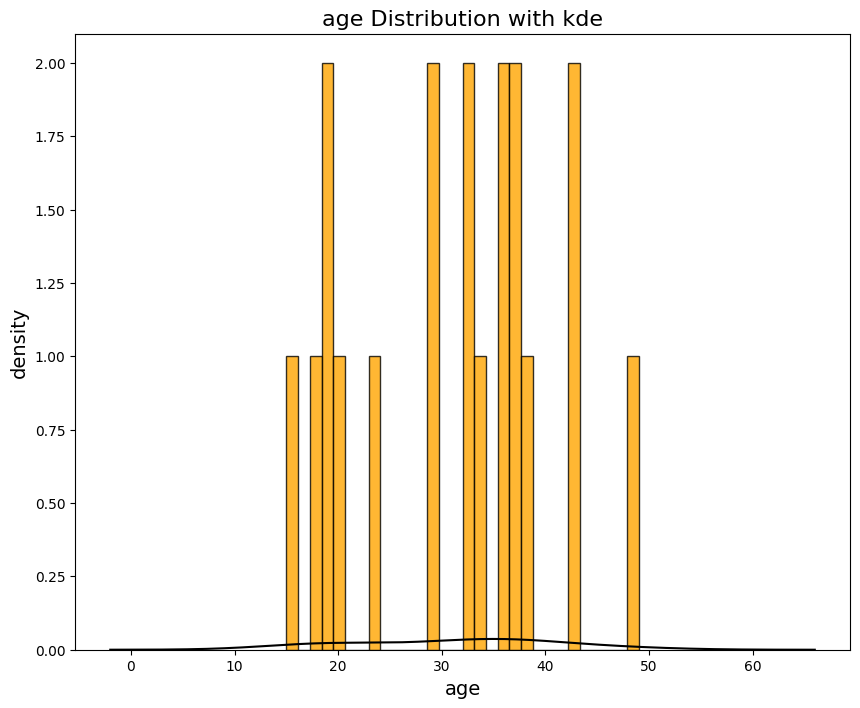

In [20]:
plt.figure(figsize=(10, 8))
emotions_df['age'].plot(kind='hist', bins = 30, color = 'orange', edgecolor = 'black', alpha = 0.8)
emotions_df['age'].plot(kind='kde', color='black')
plt.title('age Distribution with kde', fontsize = 16)
plt.xlabel('age', fontsize = 14)
plt.ylabel('density', fontsize = 14)
plt.show()

<Figure size 1000x800 with 0 Axes>

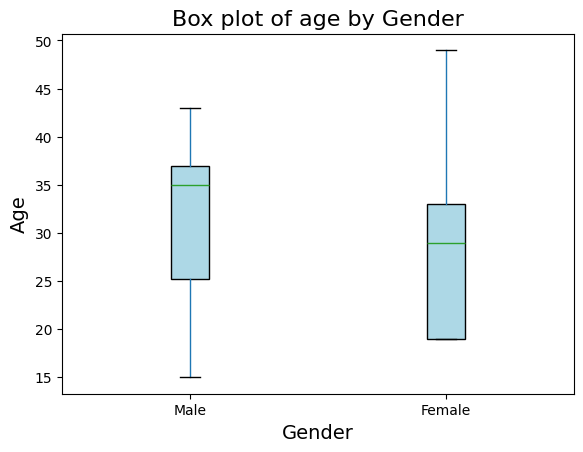

In [24]:
plt.figure(figsize=(10, 8))
emotions_df.boxplot(column = 'age', by = 'gender', grid = False, patch_artist = True, boxprops =dict(facecolor = 'lightblue'))
plt.title('Box plot of age by Gender', fontsize = 16)
plt.xlabel('Gender', fontsize = 14)
plt.suptitle('')
plt.ylabel('Age', fontsize = 14)
plt.xticks([1,2], ['Male', 'Female'])
plt.show()

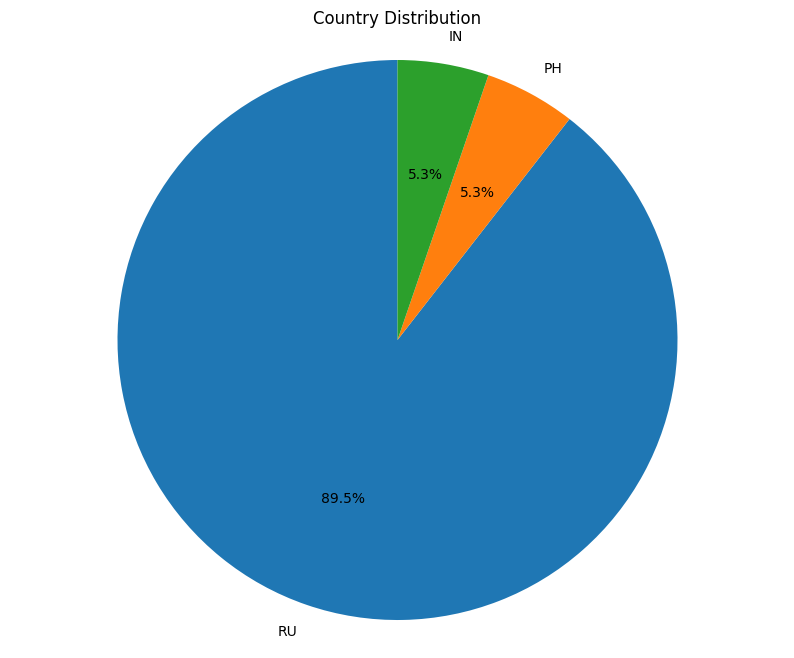

In [26]:
country_counts = emotions_df['country'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Country Distribution')
plt.axis('equal')
plt.show()

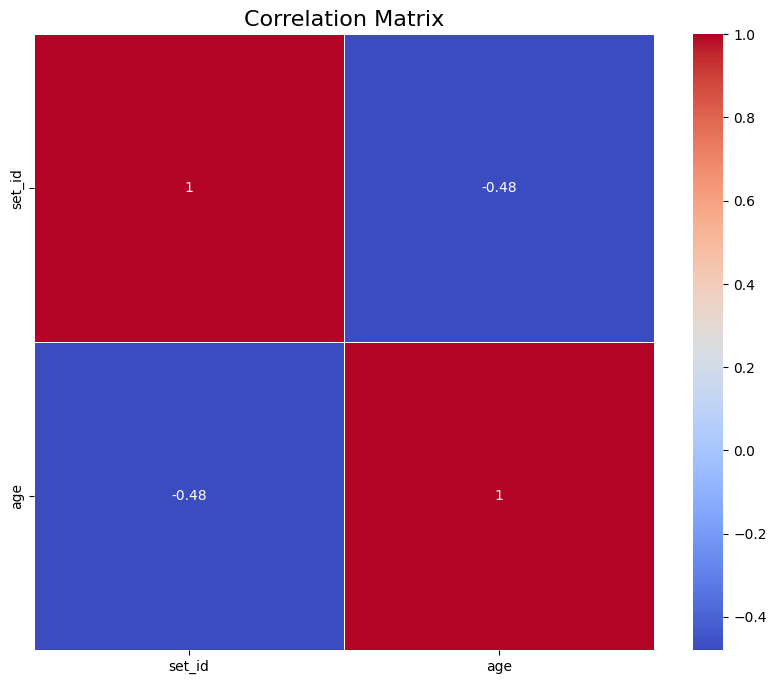

In [28]:
plt.figure(figsize = (10, 8))
numeric_cols = emotions_df.select_dtypes(include = [np.number]) # select the numeric columns as a DataFrame
corr = numeric_cols.corr() # call .corr() on the DataFrame
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 16)
plt.show()

In [29]:
label_encoder = LabelEncoder()
emotions_df['gender']= label_encoder.fit_transform(emotions_df['gender'])

In [41]:
def load_data():
  images = []
  labels = []

  for emotions_label, emotions in enumerate(EMOTIONS):
    emotions_dir = os.path.join(Data_Dir, str(emotions_label))

    if os.path.isdir(emotions_dir):
      for img_file in os.listdir(emotions_dir):
        img_path = os.path.join(emotions_dir, img_file)
        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        Img_resized = cv2.resize(img_array, (img_size, img_size))
        images.append(Img_resized)
        labels.append(emotions_label)

    else:
       print(f"Directory not found for emotion {emotions} ; {emotions_dir}")


  return np.array(images), np.array(labels)

In [48]:
images, labels = load_data()
images = images / 255.0
labels_categorical = to_categorical(labels, num_classes= len(EMOTIONS))

In [49]:
print("Distribution of emotions:")
print(pd.Series(labels).value_counts())

Distribution of emotions:
0    8
1    8
2    8
3    8
4    8
5    8
6    8
7    8
Name: count, dtype: int64


In [50]:
x_train, x_test, y_train, y_test = train_test_split(images, labels_categorical, test_size = 0.2, random_state = 42)

In [51]:
x_train = x_train.reshape(-1, img_size, img_size, 1)
x_test = x_test.reshape(-1, img_size, img_size, 1)


In [58]:
from keras.layers import Input

model = Sequential([
    Input(shape=(img_size, img_size, 1)),
    Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Conv2D(128, (3, 3), activation = 'relu', padding = 'same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation = 'relu'),
    Dropout(0.5),
    Dense(len(EMOTIONS), activation = 'softmax')
])

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(x_train, y_train, epochs = 20, validation_data = (x_test, y_test))

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step - accuracy: 0.1409 - loss: 2.0987 - val_accuracy: 0.1538 - val_loss: 2.0757
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.1671 - loss: 2.0490 - val_accuracy: 0.1538 - val_loss: 2.0479
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.1959 - loss: 2.0089 - val_accuracy: 0.0769 - val_loss: 2.0226
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2167 - loss: 1.9553 - val_accuracy: 0.0769 - val_loss: 1.9849
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.2324 - loss: 1.9384 - val_accuracy: 0.3077 - val_loss: 1.8595
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.3029 - loss: 1.7573 - val_accuracy: 0.5385 - val_loss: 1.6994
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.4257 - loss: 1.6865 - val_accuracy: 0.5385 - val_loss: 1.4942
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5065 - loss: 1.4765 - val_accuracy: 0.5385 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


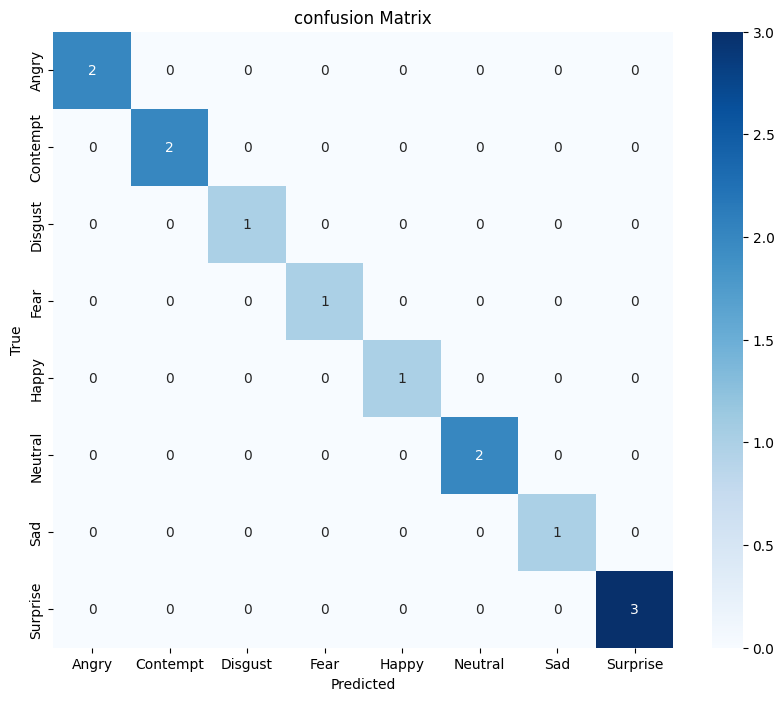

              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00         2
    Contempt       1.00      1.00      1.00         2
     Disgust       1.00      1.00      1.00         1
        Fear       1.00      1.00      1.00         1
       Happy       1.00      1.00      1.00         1
     Neutral       1.00      1.00      1.00         2
         Sad       1.00      1.00      1.00         1
    Surprise       1.00      1.00      1.00         3

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [63]:
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis = 1)
y_test_labels = np.argmax(y_test, axis = 1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_df = pd.DataFrame(cm, index = EMOTIONS, columns = EMOTIONS)
plt.figure(figsize = (10, 8))
sns.heatmap(cm_df, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

report = classification_report(y_test_labels, y_pred_labels, target_names = EMOTIONS)
print(report)


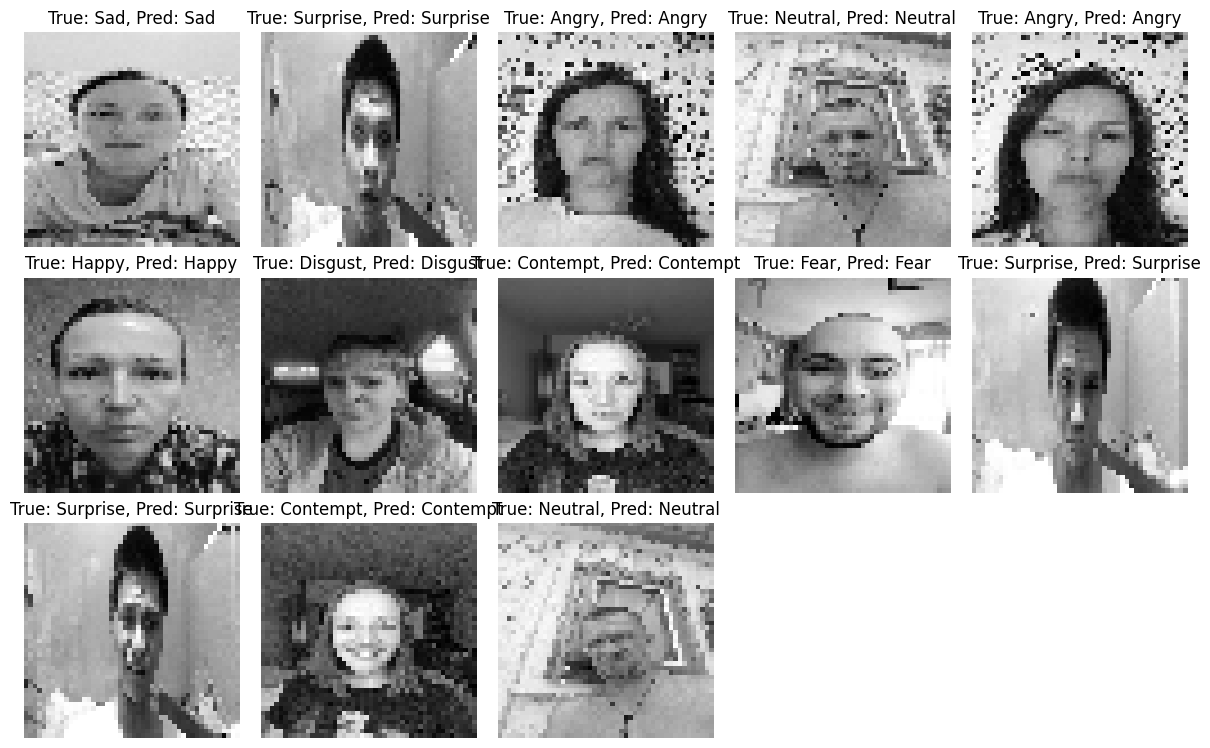

In [66]:
num_images = min(20, len(x_test))
plt.figure(figsize = (12, 10))
for i in range(num_images):
  plt.subplot(4, 5, i + 1)
  img = (x_test[i] * 255).astype(np.uint8)
  plt.imshow(img.squeeze(), cmap = 'gray')
  plt.title(f'True: {EMOTIONS[(y_test_labels[i])]}, Pred: {EMOTIONS[y_pred_labels[i]]}')
  plt.axis('off')

plt.tight_layout()
plt.show()